In [36]:
import json
import os
import subprocess
import time
import statistics
from common import *
from experiment import NetworkSetting

# Collect Data

In [2]:
# Make the directory to store raw results
SIDEKICK_HOME = f'{os.environ["HOME"]}/sidekick-downloads'
RESULTS_DIR = f'{SIDEKICK_HOME}/data/multicast'
os.chdir(SIDEKICK_HOME)
os.system(f'mkdir -p {RESULTS_DIR}')
RESULTS_DIR

'/users/ygina/sidekick-downloads/data/multicast'

In [3]:
def create_command(label, duration, num_clients, num_quackers, network_options=[], protocol_options=[]):
    """Create the command"""
    cmd = ['sudo', '-E', 'python3', 'emulation/main.py']
    cmd += ['--network-statistics', '--label', label] + network_options
    cmd += ['multicast']
    cmd += ['--duration', str(duration), '--num-clients', str(num_clients)] + protocol_options
    if num_quackers > 0:
        cmd += ['--client-quacker', str(num_quackers)]
    return cmd

def execute_command(cmd):
    """Run the command from the upper-level directory"""
    os.chdir(SIDEKICK_HOME)
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print('WARNING: non-zero returncode', result.returncode)
        print(result.stderr)
    return result.stdout, result.stderr

In [4]:
def parse_raw_results(label, duration, num_clients, num_quackers=0, network_options=[], protocol_options=[], execute=True, overwrite=False):
    filename = f'{RESULTS_DIR}/{label}.log'
    cmd = create_command(label, duration, num_clients, num_quackers, network_options, protocol_options)
    if os.path.exists(filename) and not overwrite:
        with open(filename, 'r') as f:
            stdout = f.read()
    elif execute:
        current_time = time.strftime('%l:%M%p %Z').strip()
        print(f'[{current_time}]', filename, ' '.join(cmd))
        stdout, _ = execute_command(cmd)
        with open(filename, 'w') as f:
            f.write(stdout)
    else:
        print('MISSING:', filename, ' '.join(cmd))
        return
    result = json.loads(stdout)
    return result['outputs'][0]

In [68]:
base_network_options = lambda far_loss: ['--bw1', '10', '--bw2', '100', '--delay1', '25', '--delay2', '1', '--loss1', '0', '--loss2', str(far_loss),]
quacker_options = ['--threshold', '8', '--freq-pkts', '50', '--freq-ms', '1000']
results = {}
options = {
    'baseline': ([], []),
    # 'sidekick': (['--proxy', 'sidekick-multicast'], []),
    'sidekick_delay15': (['--proxy', 'sidekick-multicast'], ['--ack-delay', '15']),
    'sidekick_delay30': (['--proxy', 'sidekick-multicast'], ['--ack-delay', '30']),
    'sidekick_delay45': (['--proxy', 'sidekick-multicast'], ['--ack-delay', '45']),
    'sidekick_delay60': (['--proxy', 'sidekick-multicast'], ['--ack-delay', '60']),
}
labels = list(options.keys())

def set_result(base_label, duration, num_clients, num_quackers=0, execute=True, overwrite=False):
    network_options, protocol_options = options[base_label]
    label = f'{base_label}_{duration}_{num_clients}_{num_quackers}'
    result = parse_raw_results(
        label, duration, num_clients, num_quackers, execute=execute, overwrite=overwrite,
        network_options=base_network_options('3.6') + quacker_options + network_options,
        protocol_options=protocol_options,
    )
    results[base_label] = result

In [75]:
duration = 120
num_clients = 10
num_quackers = num_clients
execute = True
set_result('baseline', duration, num_clients, 0, execute=execute)

In [23]:
set_result('sidekick', duration, num_clients, num_quackers, execute=True)

KeyError: 'sidekick'

In [69]:
set_result('sidekick_delay15', duration, num_clients, num_quackers, execute=True, overwrite=True)

[3:51PM EST] /users/ygina/sidekick-downloads/data/multicast/sidekick_delay15_120_10_10.log sudo -E python3 emulation/main.py --network-statistics --label sidekick_delay15_120_10_10 --bw1 10 --bw2 100 --delay1 25 --delay2 1 --loss1 0 --loss2 3.6 --threshold 8 --freq-pkts 50 --freq-ms 1000 --proxy sidekick-multicast multicast --duration 120 --num-clients 10 --ack-delay 15 --client-quacker 10


In [74]:
set_result('sidekick_delay30', duration, num_clients, num_quackers, execute=True)

In [70]:
set_result('sidekick_delay45', duration, num_clients, num_quackers, execute=True, overwrite=True)

[3:53PM EST] /users/ygina/sidekick-downloads/data/multicast/sidekick_delay45_120_10_10.log sudo -E python3 emulation/main.py --network-statistics --label sidekick_delay45_120_10_10 --bw1 10 --bw2 100 --delay1 25 --delay2 1 --loss1 0 --loss2 3.6 --threshold 8 --freq-pkts 50 --freq-ms 1000 --proxy sidekick-multicast multicast --duration 120 --num-clients 10 --ack-delay 45 --client-quacker 10


In [71]:
set_result('sidekick_delay60', duration, num_clients, num_quackers, execute=True, overwrite=True)

[3:55PM EST] /users/ygina/sidekick-downloads/data/multicast/sidekick_delay60_120_10_10.log sudo -E python3 emulation/main.py --network-statistics --label sidekick_delay60_120_10_10 --bw1 10 --bw2 100 --delay1 25 --delay2 1 --loss1 0 --loss2 3.6 --threshold 8 --freq-pkts 50 --freq-ms 1000 --proxy sidekick-multicast multicast --duration 120 --num-clients 10 --ack-delay 60 --client-quacker 10


In [73]:
# check results
def check_multicast_output(output, num_clients):
    assert output.get('success')
    assert len(output.get('client_ids')) == num_clients
    assert len(output.get('latencies')) == num_clients
    assert len(output.get('num_spurious')) == num_clients

for label in results:
    print(label)
    check_multicast_output(results[label], num_clients)
print('all good')

sidekick_delay15
sidekick_delay45
sidekick_delay60
all good


# Plot CDF Data

In [29]:
def preprocess_latencies(latencies, num_ticks=100):
    ticks = []
    latencies.sort()
    for i in range(num_ticks):
        index = int(i * len(latencies) / num_ticks)
        ticks.append(latencies[index])
    ticks.append(latencies[-1])
    # Convert ns to ms
    return [tick / 1000000.0 for tick in ticks]

In [30]:
def plot_delay_cdf(output, title, min_pct=86, num_ticks=1000):
    latencies_data = {}
    num_clients = len(output['client_ids'])
    for i in range(num_clients):
        client_id = output['client_ids'][i]
        latencies = output['latencies'][i]
        latencies_data[client_id] = latencies
    client_ids = list(sorted(latencies_data.keys()))
    
    plt.figure(figsize=(6, 4))
    for client_id in client_ids:
        data = latencies_data[client_id]
        data = preprocess_latencies(data, num_ticks=num_ticks)
        ys = [i / len(data) * 100.0 for i in range(len(data))]
        plt.plot(data, ys, label=client_id)
    plt.xlabel('De-Jitter Latency (ms)')
    plt.xticks()
    plt.xlim(0)

    plt.ylabel('Percentile')
    ticks = [tick for tick in range(min_pct, num_ticks + 1, 2)]
    plt.yticks(ticks=ticks, labels=[f'{tick}%' for tick in ticks])
    plt.yticks()
    plt.ylim(min_pct, 100.5)

    plt.grid()
    plt.title(title)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.4), ncol=6)
    plt.show()

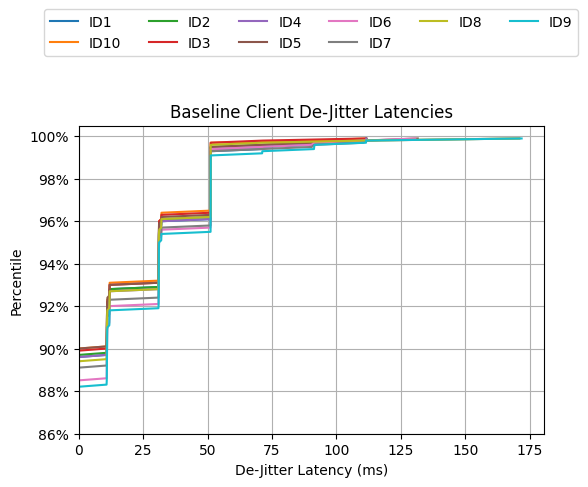

In [76]:
plot_delay_cdf(results['baseline'], title='Baseline Client De-Jitter Latencies')

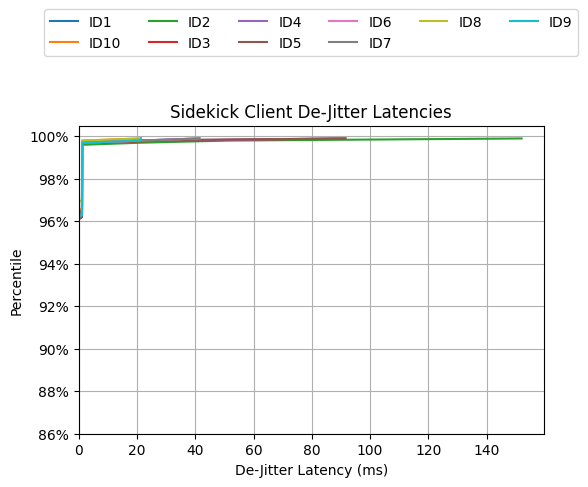

In [80]:
plot_delay_cdf(results['sidekick_delay30'], title='Sidekick Client De-Jitter Latencies')

# Plot network statistics

In [62]:
def plot_network_statistics_one_trial(output, title, statistic):
    output = output['statistics']
    data = {}
    for i, iface in enumerate(output['ifaces']):
        data[iface] = output[statistic][i]
    ifaces = list(sorted(filter(lambda iface: iface.startswith('h'), output['ifaces'])))
    width = 0.8 / len(ifaces)
    for i, iface in enumerate(ifaces):
        value = data[iface]
        plt.bar([i * width], value, width=width, label=iface)

    plt.ylabel(statistic)
    plt.ylim(0)

    plt.grid(axis='y')
    plt.title(title)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.4), ncol=5)
    plt.show()

In [64]:
def plot_network_statistics(labels, results, ifaces, statistic, title):
    width = 0.8 / len(labels)
    for i, label in enumerate(labels):
        output = results[label]['statistics']
        values = []
        for index, iface in enumerate(output['ifaces']):
            if iface in ifaces:
                values.append(output[statistic][index])
        mean = statistics.mean(values)
        std = None if len(values) <= 1 else statistics.stdev(values)
        plt.bar([i * width], mean, yerr=std, width=width, label=label)

    plt.ylabel(statistic)
    plt.ylim(0)
    plt.grid(axis='y')
    plt.title(title)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=3)
    plt.show()

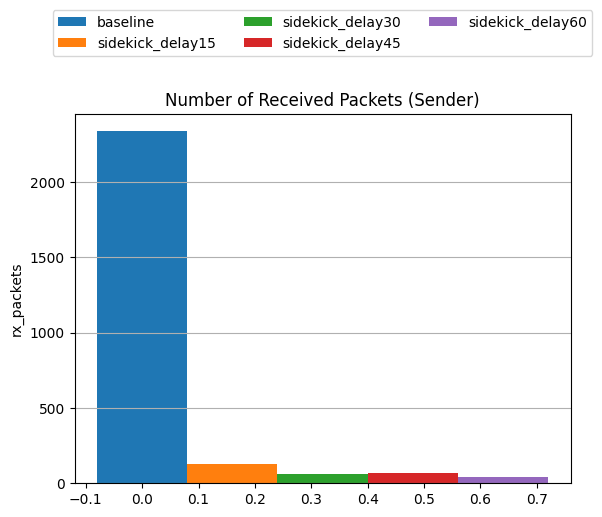

In [81]:
# Number of received packets at h0-eth0 for each treatment
# The multicast sender processes much fewer NACKs per second
plot_network_statistics(labels, results, ifaces=['h0-eth0'], statistic='rx_packets', title='Number of Received Packets (Sender)')

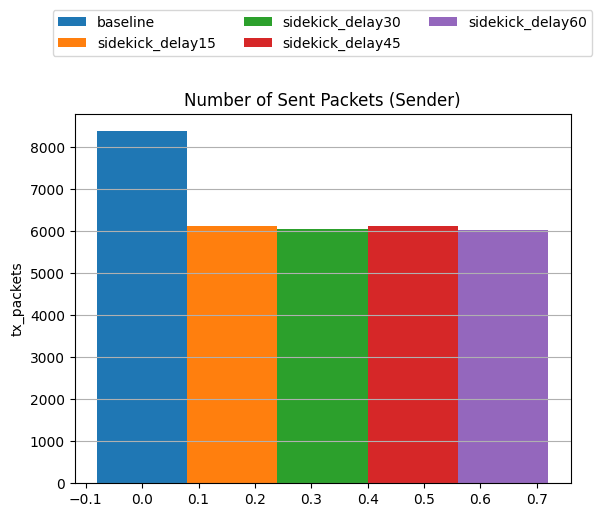

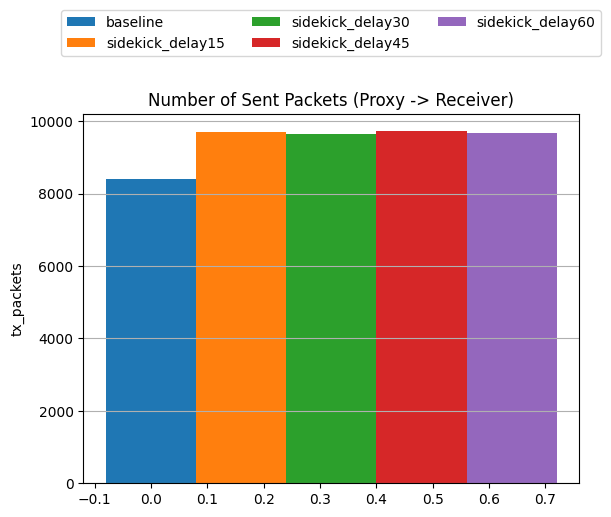

In [96]:
# Number of sent packets at h0-eth0 for each treatment
# Fewer packets saturating the core network
plot_network_statistics(labels, results, ifaces=['h0-eth0'], statistic='tx_packets', title='Number of Sent Packets (Sender)')
plot_network_statistics(labels, results, ifaces=['p1-eth1'], statistic='tx_packets', title='Number of Sent Packets (Proxy -> Receiver)')

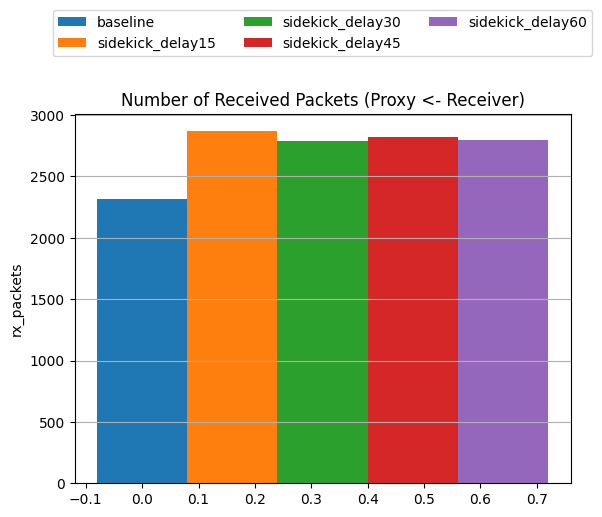

In [94]:
# Number of received packets at p1-eth1 for each treatment
# Low data overheads of using the quACK at the proxy
plot_network_statistics(labels, results, ifaces=['p1-eth1'], statistic='rx_packets', title='Number of Received Packets (Proxy <- Receiver)')

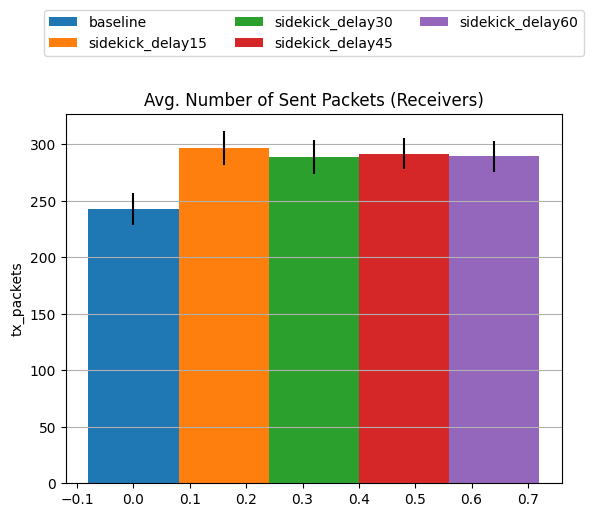

In [93]:
# Average number of sent packets at h1-eth0 to h10-eth0 for each treatment
plot_network_statistics(labels, results, ifaces=[f'h{i}-eth0' for i in range(1, 11)], statistic='tx_packets', title='Avg. Number of Sent Packets (Receivers)')

In [84]:
# output = results['baseline']
# plot_network_statistics_one_trial(output, title='Number of Sent Packets', statistic='tx_packets')
# plot_network_statistics_one_trial(output, title='Number of Received Packets', statistic='rx_packets')

In [85]:
# output = results['sidekick']
# plot_network_statistics_one_trial(output, title='Number of Sent Packets', statistic='tx_packets')
# plot_network_statistics_one_trial(output, title='Number of Received Packets', statistic='rx_packets')

Number of sent packets:
* h0-eth0-send = frequency * time
* hn-eth0-send = h0-eth0-send * loss

Number of received packets:
* h0-eth0-recv = hn-eth0-send * num_clients
* hn-eth0-recv = h0-eth0-send - hn-eth0-send

# Plot num spurious

In [89]:
def plot_num_spurious(labels, results, title):
    width = 0.8 / len(labels)
    for i, label in enumerate(labels):
        values = results[label]['num_spurious']
        mean = statistics.mean(values)
        std = None if len(values) <= 1 else statistics.stdev(values)
        plt.bar([i * width], mean, yerr=std, width=width, label=label)

    plt.ylabel('Num Packets')
    plt.ylim(0)
    plt.grid(axis='y')
    plt.title(title)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=3)
    plt.show()

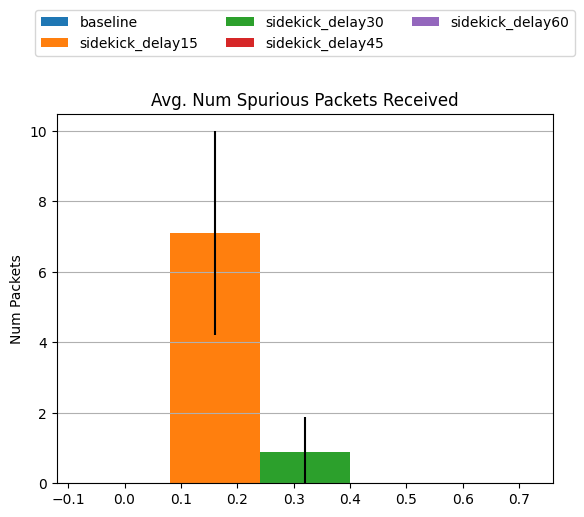

In [91]:
plot_num_spurious(labels, results, title="Avg. Num Spurious Packets Received")